In [1]:
########################
# INFO 523 Final Project
########################


In [2]:
########################
#  Import packages and export folder
########################

import os
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from itertools import combinations
from scipy.stats import mannwhitneyu, kruskal, f_oneway
from statsmodels.stats.multitest import multipletests

# Global style
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12
})

output_dir = "figures"
os.makedirs(output_dir, exist_ok=True)

In [3]:
############################
# Load dataset
############################

file_path = "LLCP2024.XPT"

df_raw, meta = pyreadstat.read_xport(
    file_path,
    encoding="latin1"
)

print(df_raw.shape)
df_raw.head()

(457670, 301)


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,02282024,02,28,2024,1100.0,2024000001,2.024000e+09,1.0,...,NaN,9.0,2.0,0.0,1.0,0.0,1.0,1.0,2.0,2.0
1,1.0,2.0,02212024,02,21,2024,1100.0,2024000002,2.024000e+09,1.0,...,4.0,9.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0
2,1.0,2.0,02212024,02,21,2024,1100.0,2024000003,2.024000e+09,1.0,...,4.0,2.0,1.0,100.0,2.0,1400.0,1.0,NaN,NaN,2.0
3,1.0,2.0,02282024,02,28,2024,1100.0,2024000004,2.024000e+09,1.0,...,NaN,9.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0
4,1.0,2.0,02212024,02,21,2024,1100.0,2024000005,2.024000e+09,1.0,...,3.0,9.0,2.0,0.0,1.0,0.0,1.0,NaN,NaN,2.0


In [4]:
###############################
# Select final variables
###############################

vars_keep = [
    "GENHLTH", "PHYSHLTH", "MENTHLTH",
    "EXERANY2", "SMOKE100", "SMOKDAY2", "DRNKANY6",
    "ADDEPEV3", "HAVARTH4", "ASTHMA3", "CVDINFR4",
    "PRIMINS2", "MEDCOST1", "PERSDOC3", "CHECKUP1",
    "DIFFWALK", "DIFFDRES",
    "_AGEG5YR", "SEXVAR", "EDUCA", "INCOME3"
]


missing_vars = [v for v in vars_keep if v not in df_raw.columns]
missing_vars

[]

In [5]:
##################################
# Data Cleaning and complete case construction
##################################

df_selected = df_raw[vars_keep].copy()

df_clean = df_selected.replace({
    7: np.nan, 9: np.nan,
    77: np.nan, 99: np.nan,
    777: np.nan, 999: np.nan
})

df_complete = df_clean.dropna().copy()

print("Before complete case:", df_selected.shape)
print("After complete case:", df_complete.shape)

Before complete case: (457670, 21)
After complete case: (62367, 21)


In [6]:
################################
#  Recode binary variables
################################

binary_vars = [
    "EXERANY2", "SMOKE100", "ADDEPEV3", "HAVARTH4",
    "ASTHMA3", "CVDINFR4", "MEDCOST1",
    "DIFFWALK", "DIFFDRES"
]

for col in binary_vars:
    df_complete[col] = df_complete[col].map({1: 1, 2: 0})

In [7]:
################################
# Create Jaccard dataset
################################

jaccard_vars = [
    "EXERANY2", "SMOKE100", "ADDEPEV3",
    "HAVARTH4", "ASTHMA3", "CVDINFR4",
    "MEDCOST1", "DIFFWALK", "DIFFDRES"
]

df_jaccard = df_complete[jaccard_vars].copy()

df_jaccard.head()

,EXERANY2,SMOKE100,ADDEPEV3,HAVARTH4,ASTHMA3,CVDINFR4,MEDCOST1,DIFFWALK,DIFFDRES
1,1,1,0,1,0,0,0,0,0
11,0,1,0,1,0,0,0,0,0
12,1,1,1,1,0,0,0,0,0
14,1,1,0,0,0,1,0,1,0
15,1,1,0,1,0,0,0,0,0


In [8]:
##################################
# One-Hot Encoding of Categorical Variables
##################################

df_full = pd.get_dummies(
    df_complete,
    columns=["PRIMINS2", "PERSDOC3"],
    drop_first=True
)

df_full.shape

(62367, 29)

In [9]:
##################################
# Save cleaned datasets
##################################

df_full.to_csv("clean_full_dataset.csv", index=False)
df_jaccard.to_csv("jaccard_dataset.csv", index=False)

print("Saved clean_full_dataset.csv")
print("Saved jaccard_dataset.csv")

Saved clean_full_dataset.csv
Saved jaccard_dataset.csv


In [10]:
##################################
# Prepare modeling data
##################################

# Use a sample for speed
sample_n = 3000

df_full_sample = df_full.sample(sample_n, random_state=42)
df_jaccard_sample = df_jaccard.loc[df_full_sample.index]

scaler = StandardScaler()
X_full = scaler.fit_transform(df_full_sample)

X_jaccard = df_jaccard_sample.values

In [11]:
##################################
# Define bootstrap medoids
##################################

def bootstrap_kmedoids_ari(X, metric, k= 4, n_bootstrap=100, sample_size=1500):
    rng = np.random.default_rng(42)
    ari_scores = []

    for i in range(n_bootstrap):
        idx1 = rng.choice(X.shape[0], size=sample_size, replace=True)
        idx2 = rng.choice(X.shape[0], size=sample_size, replace=True)

        common, pos1, pos2 = np.intersect1d(idx1, idx2, return_indices=True)

        if len(common) < 50:
            continue

        model1 = KMedoids(
            n_clusters=k,
            metric=metric,
            method="alternate",
            init="k-medoids++",
            random_state=i
        )

        model2 = KMedoids(
            n_clusters=k,
            metric=metric,
            method="alternate",
            init="k-medoids++",
            random_state=i + 1000
        )

        labels1 = model1.fit_predict(X[idx1])
        labels2 = model2.fit_predict(X[idx2])

        ari = adjusted_rand_score(labels1[pos1], labels2[pos2])
        ari_scores.append(ari)

    return ari_scores

In [12]:
#################################
# Run multi-k clustering stability experiment
#################################

k_values = [3, 4, 5]
n_bootstrap = 100
sample_size = 1500

results = []

for k in k_values:
    for metric in ["euclidean", "manhattan", "cosine"]:
        print(f"Running {metric}, k={k}...")

        scores = bootstrap_kmedoids_ari(
            X_full,
            metric=metric,
            k=k,
            n_bootstrap=n_bootstrap,
            sample_size=sample_size
        )

        for score in scores:
            results.append({
                "k": k,
                "metric": metric,
                "ARI": score
            })

    print(f"Running jaccard, k={k}...")

    scores = bootstrap_kmedoids_ari(
        X_jaccard.astype(bool),
        metric="jaccard",
        k=k,
        n_bootstrap=n_bootstrap,
        sample_size=sample_size
    )

    for score in scores:
        results.append({
            "k": k,
            "metric": "jaccard",
            "ARI": score
        })

results_df = pd.DataFrame(results)
results_df.head()

Running euclidean, k=3...


e:\venv\info523\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
e:\venv\info523\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
e:\venv\info523\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
e:\venv\info523\Lib\si

Running manhattan, k=3...


e:\venv\info523\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
e:\venv\info523\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
e:\venv\info523\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
e:\venv\info523\Lib\si

Running cosine, k=3...


...

Running cosine, k=5...


e:\venv\info523\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
e:\venv\info523\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
e:\venv\info523\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
e:\venv\info523\Lib\si

Running jaccard, k=5...


e:\venv\info523\Lib\site-packages\sklearn\metrics\pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
e:\venv\info523\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
e:\venv\info523\Lib\site-packages\sklearn\metrics\pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
e:\venv\info523\Lib\site-packages\sklearn\metrics\pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
e:\venv\info523\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `s

,k,metric,ARI
0,3,euclidean,0.091901
1,3,euclidean,0.435547
2,3,euclidean,0.250432
3,3,euclidean,0.206235
4,3,euclidean,0.154657


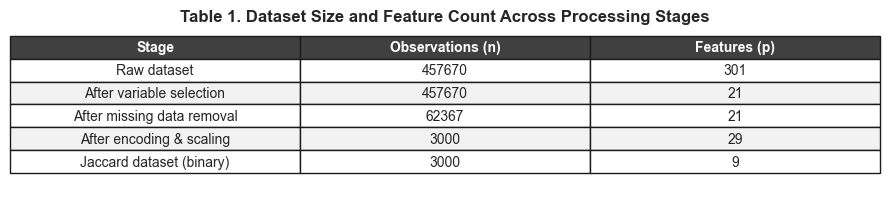

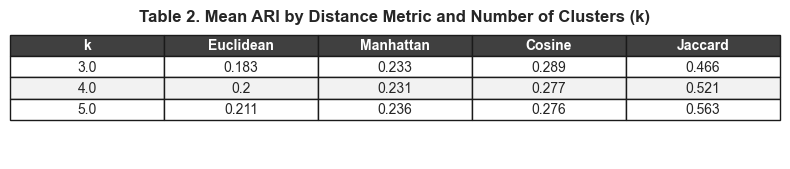

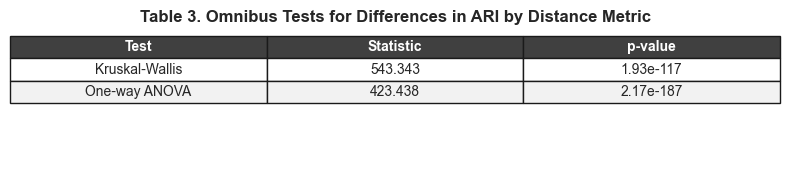

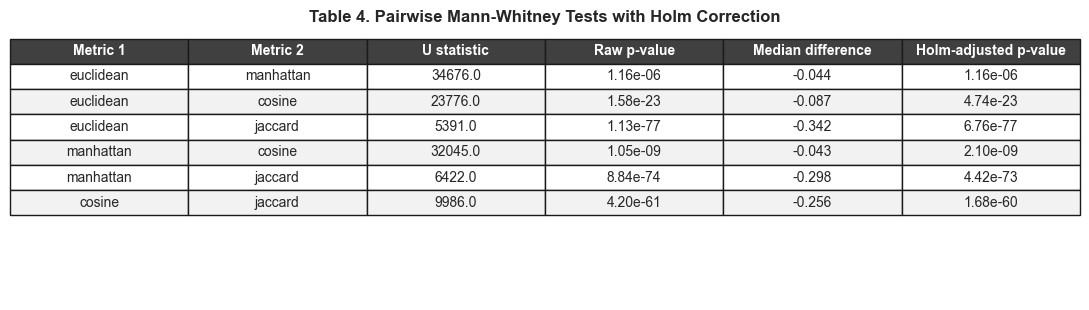

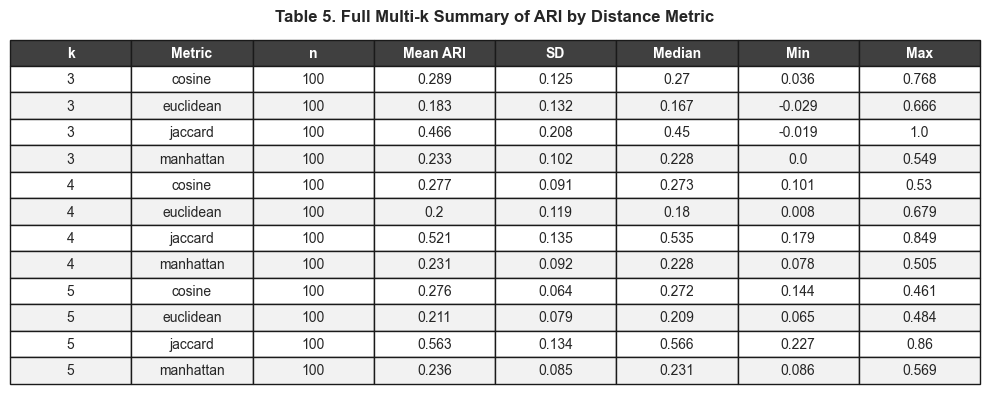

,Stage,Observations (n),Features (p)
0,Raw dataset,457670,301
1,After variable selection,457670,21
2,After missing data removal,62367,21
3,After encoding & scaling,3000,29
4,Jaccard dataset (binary),3000,9


metric,k,Euclidean,Manhattan,Cosine,Jaccard
0,3,0.183,0.233,0.289,0.466
1,4,0.200,0.231,0.277,0.521
2,5,0.211,0.236,0.276,0.563


,Test,Statistic,p-value
0,Kruskal-Wallis,543.343,1.93e-117
1,One-way ANOVA,423.438,2.17e-187


,Metric 1,Metric 2,U statistic,Raw p-value,Median difference,Holm-adjusted p-value
0,euclidean,manhattan,34676.0,1.16e-06,-0.044,1.16e-06
1,euclidean,cosine,23776.0,1.58e-23,-0.087,4.74e-23
2,euclidean,jaccard,5391.0,1.13e-77,-0.342,6.76e-77
3,manhattan,cosine,32045.0,1.05e-09,-0.043,2.10e-09
4,manhattan,jaccard,6422.0,8.84e-74,-0.298,4.42e-73
5,cosine,jaccard,9986.0,4.20e-61,-0.256,1.68e-60


,k,Metric,n,Mean ARI,SD,Median,Min,Max
0,3,cosine,100,0.289,0.125,0.270,0.036,0.768
1,3,euclidean,100,0.183,0.132,0.167,-0.029,0.666
2,3,jaccard,100,0.466,0.208,0.450,-0.019,1.000
3,3,manhattan,100,0.233,0.102,0.228,0.000,0.549
4,4,cosine,100,0.277,0.091,0.273,0.101,0.530
5,4,euclidean,100,0.200,0.119,0.180,0.008,0.679
6,4,jaccard,100,0.521,0.135,0.535,0.179,0.849
7,4,manhattan,100,0.231,0.092,0.228,0.078,0.505
8,5,cosine,100,0.276,0.064,0.272,0.144,0.461
9,5,euclidean,100,0.211,0.079,0.209,0.065,0.484


In [ ]:
####################################
# Tables: Summary + Statistical Tests
####################################

def export_table_png(df, filename, title, figsize=None, fontsize=10):
    n_rows = len(df) + 1  # includes header

    # Auto-size height based on number of rows
    if figsize is None:
        width = 11 if len(df.columns) > 4 else 8
        height = 0.45 + (0.32 * n_rows)
        figsize = (width, height)

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.35)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold", color="white")
            cell.set_facecolor("#404040")
        else:
            cell.set_facecolor("#f2f2f2" if row % 2 == 0 else "#ffffff")

    ax.set_title(title, fontsize=12, weight="bold", pad=4)

    plt.savefig(
        f"{output_dir}/{filename}",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.03
    )

    plt.show()
    plt.close()


####################################
# Table 1: Dataset size summary
####################################

n_raw, p_raw = df_raw.shape
n_selected, p_selected = df_selected.shape
n_complete, p_complete = df_complete.shape

summary_sizes = pd.DataFrame({
    "Stage": [
        "Raw dataset",
        "After variable selection",
        "After missing data removal",
        "After encoding & scaling",
        "Jaccard dataset (binary)"
    ],
    "Observations (n)": [
        n_raw,
        n_selected,
        n_complete,
        X_full.shape[0],
        X_jaccard.shape[0]
    ],
    "Features (p)": [
        p_raw,
        p_selected,
        p_complete,
        X_full.shape[1],
        X_jaccard.shape[1]
    ]
})

summary_sizes_display = summary_sizes.copy()
summary_sizes_display["Observations (n)"] = summary_sizes_display["Observations (n)"].astype(int)
summary_sizes_display["Features (p)"] = summary_sizes_display["Features (p)"].astype(int)

summary_sizes_display.to_csv(
    f"{output_dir}/table1_dataset_size_summary.csv",
    index=False
)

export_table_png(
    summary_sizes_display,
    "table1_dataset_size_summary.png",
    "Table 1. Dataset Size and Feature Count Across Processing Stages",
    figsize=(9, 2.2),
    fontsize=10
)


####################################
# Table 2: Mean ARI by k and metric
####################################

summary_k = results_df.groupby(["k", "metric"])["ARI"].agg(
    ["count", "mean", "std", "median", "min", "max"]
).reset_index()

summary_wide = summary_k.pivot(
    index="k",
    columns="metric",
    values="mean"
).round(3)

summary_wide = summary_wide[["euclidean", "manhattan", "cosine", "jaccard"]]

summary_wide_display = summary_wide.reset_index().rename(columns={
    "k": "k",
    "euclidean": "Euclidean",
    "manhattan": "Manhattan",
    "cosine": "Cosine",
    "jaccard": "Jaccard"
})

summary_wide_display["k"] = summary_wide_display["k"].astype(int)

summary_wide_display.to_csv(
    f"{output_dir}/table2_mean_ari_wide.csv",
    index=False
)

export_table_png(
    summary_wide_display,
    "table2_mean_ari_wide.png",
    "Table 2. Mean ARI by Distance Metric and Number of Clusters (k)",
    fontsize=10
)


####################################
# Table 3: Omnibus tests
####################################

groups = [
    group["ARI"].values
    for _, group in results_df.groupby("metric")
]

kw_stat, kw_p = kruskal(*groups)
anova_stat, anova_p = f_oneway(*groups)

stats_table = pd.DataFrame({
    "Test": ["Kruskal-Wallis", "One-way ANOVA"],
    "Statistic": [kw_stat, anova_stat],
    "p-value": [kw_p, anova_p]
})

stats_table_display = stats_table.copy()
stats_table_display["Statistic"] = stats_table_display["Statistic"].round(3)
stats_table_display["p-value"] = stats_table_display["p-value"].apply(lambda x: f"{x:.2e}")

stats_table.to_csv(
    f"{output_dir}/table3_omnibus_tests.csv",
    index=False
)

export_table_png(
    stats_table_display,
    "table3_omnibus_tests.png",
    "Table 3. Omnibus Tests for Differences in ARI by Distance Metric",
    fontsize=10
)


####################################
# Table 4: Pairwise tests
####################################

pairwise_results = []

for m1, m2 in combinations(results_df["metric"].unique(), 2):
    x = results_df.loc[results_df["metric"] == m1, "ARI"]
    y = results_df.loc[results_df["metric"] == m2, "ARI"]

    stat, p = mannwhitneyu(x, y, alternative="two-sided")

    pairwise_results.append({
        "Metric 1": m1,
        "Metric 2": m2,
        "U statistic": stat,
        "Raw p-value": p,
        "Median difference": x.median() - y.median()
    })

pairwise_df = pd.DataFrame(pairwise_results)

pairwise_df["Holm-adjusted p-value"] = multipletests(
    pairwise_df["Raw p-value"],
    method="holm"
)[1]

pairwise_display = pairwise_df.copy()
pairwise_display["U statistic"] = pairwise_display["U statistic"].round(1)
pairwise_display["Median difference"] = pairwise_display["Median difference"].round(3)
pairwise_display["Raw p-value"] = pairwise_display["Raw p-value"].apply(lambda x: f"{x:.2e}")
pairwise_display["Holm-adjusted p-value"] = pairwise_display["Holm-adjusted p-value"].apply(lambda x: f"{x:.2e}")

pairwise_df.to_csv(
    f"{output_dir}/table4_pairwise_tests.csv",
    index=False
)

export_table_png(
    pairwise_display,
    "table4_pairwise_tests.png",
    "Table 4. Pairwise Mann-Whitney Tests with Holm Correction",
    fontsize=10
)

####################################
# Optional supporting table: full multi-k summary
####################################

summary_k_display = summary_k.copy().round(3)
summary_k_display["k"] = summary_k_display["k"].astype(int)

summary_k_display = summary_k_display.rename(columns={
    "k": "k",
    "metric": "Metric",
    "count": "n",
    "mean": "Mean ARI",
    "std": "SD",
    "median": "Median",
    "min": "Min",
    "max": "Max"
})

summary_k_display.to_csv(
    f"{output_dir}/table5_full_multik_summary.csv",
    index=False
)

export_table_png(
    summary_k_display,
    "table5_full_multik_summary.png",
    "Table 5. Full Multi-k Summary of ARI by Distance Metric",
    figsize=(10, 4.2),
    fontsize=10
)


####################################
# Display tables in notebook
####################################

display(summary_sizes_display)
display(summary_wide_display)
display(stats_table_display)
display(pairwise_display)
display(summary_k_display)

In [14]:
# Export CSVs
summary_sizes_display.to_csv(f"{output_dir}/table1_data_summary.csv", index=False)
summary_wide_display.to_csv(f"{output_dir}/table2_mean_ari_wide.csv", index=False)
summary_k_display.to_csv(f"{output_dir}/table3_full_multik_summary.csv", index=False)
summary_overall_display.to_csv(f"{output_dir}/table4_overall_summary.csv", index=False)


# Export PNGs
export_table_png(
    summary_sizes_display,
    "table1_data_summary.png",
    "Table 1. Dataset Size and Feature Count Across Processing Stages",
    figsize=(9, 2.2),
    fontsize=10
)

export_table_png(
    summary_wide_display,
    "table3_mean_ari_wide.png",
    "Table 3. Mean ARI by Distance Metric and Number of Clusters (k)",
    figsize=(8, 1.8),
    fontsize=10
)

export_table_png(
    summary_overall_display,
    "table4_overall_summary.png",
    "Table 4. Overall ARI Summary by Distance Metric",
    figsize=(8, 1.9),
    fontsize=10
)

export_table_png(
    summary_k_display,
    "table5_full_multik_summary.png",
    "Table 5. Full Multi-k Summary of ARI by Distance Metric",
    figsize=(10, 4.2),
    fontsize=8
)



NameError: name 'summary_overall_display' is not defined

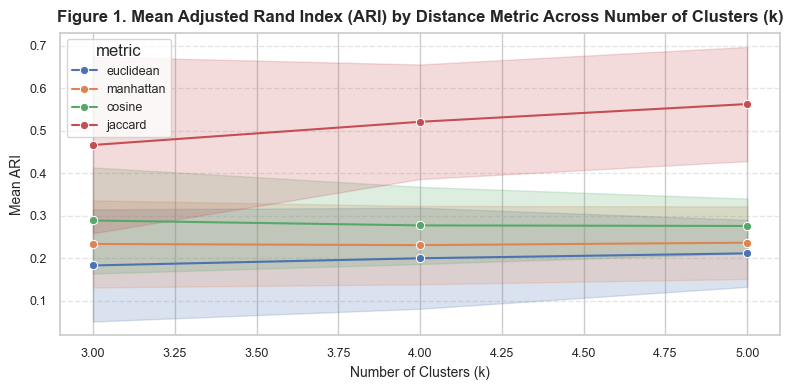

In [ ]:
################################
# Create Visualizations
################################

# Figure 1 - ARI vs. k

plt.figure(figsize=(8, 4))

sns.lineplot(
    data=results_df,
    x="k",
    y="ARI",
    hue="metric",
    estimator="mean",
    errorbar="sd",   # modern replacement for ci="sd"
    marker="o"
)

plt.title(
    "Figure 1. Mean Adjusted Rand Index (ARI) by Distance Metric Across Number of Clusters (k)",
    weight="bold",
    pad=8
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Mean ARI")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    f"{output_dir}/figure1_ari_vs_k.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

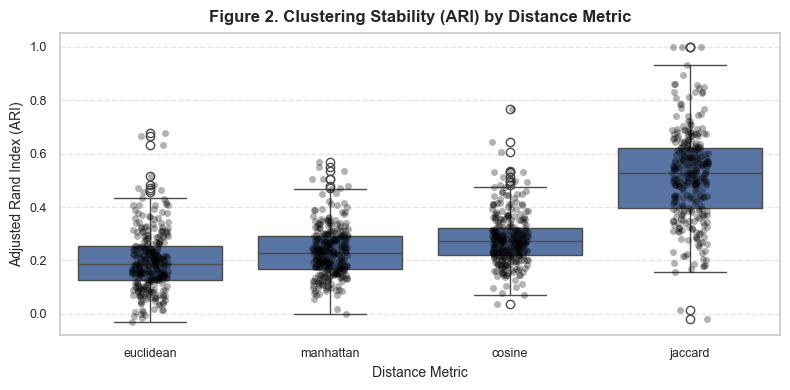

In [ ]:
################################
# Figure 2 - Boxplot
################################

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=results_df,
    x="metric",
    y="ARI"
)

sns.stripplot(
    data=results_df,
    x="metric",
    y="ARI",
    color="black",
    alpha=0.3,
    jitter=True
)

plt.title(
    "Figure 2. Clustering Stability (ARI) by Distance Metric",
    weight="bold",
    pad=8
)

plt.xlabel("Distance Metric")
plt.ylabel("Adjusted Rand Index (ARI)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    f"{output_dir}/figure2_boxplot_ari_by_metric.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

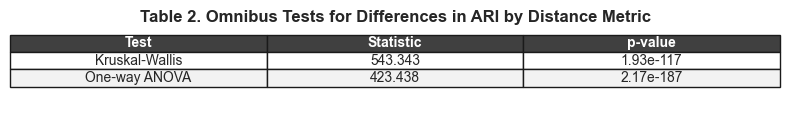

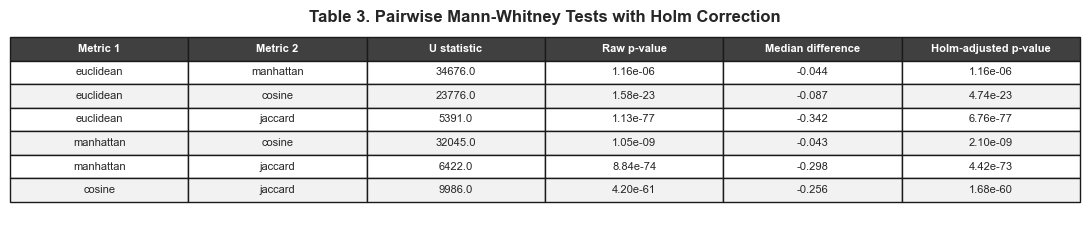

,Test,Statistic,p-value
0,Kruskal-Wallis,543.343,1.93e-117
1,One-way ANOVA,423.438,2.17e-187


,Metric 1,Metric 2,U statistic,Raw p-value,Median difference,Holm-adjusted p-value
0,euclidean,manhattan,34676.0,1.16e-06,-0.044,1.16e-06
1,euclidean,cosine,23776.0,1.58e-23,-0.087,4.74e-23
2,euclidean,jaccard,5391.0,1.13e-77,-0.342,6.76e-77
3,manhattan,cosine,32045.0,1.05e-09,-0.043,2.10e-09
4,manhattan,jaccard,6422.0,8.84e-74,-0.298,4.42e-73
5,cosine,jaccard,9986.0,4.20e-61,-0.256,1.68e-60


In [ ]:
####################################
# Statistical test tables
####################################

# Omnibus tests
groups = [
    group["ARI"].values
    for _, group in results_df.groupby("metric")
]

kw_stat, kw_p = kruskal(*groups)
anova_stat, anova_p = f_oneway(*groups)

stats_table = pd.DataFrame({
    "Test": ["Kruskal-Wallis", "One-way ANOVA"],
    "Statistic": [kw_stat, anova_stat],
    "p-value": [kw_p, anova_p]
})

stats_table_display = stats_table.copy()
stats_table_display["Statistic"] = stats_table_display["Statistic"].round(3)
stats_table_display["p-value"] = stats_table_display["p-value"].apply(lambda x: f"{x:.2e}")

stats_table.to_csv(f"{output_dir}/table2_omnibus_tests.csv", index=False)

export_table_png(
    stats_table_display,
    "table2_omnibus_tests.png",
    "Table 2. Omnibus Tests for Differences in ARI by Distance Metric",
    figsize=(8, 1.25),
    fontsize=10
)


# Pairwise tests
pairwise_results = []

for m1, m2 in combinations(results_df["metric"].unique(), 2):
    x = results_df.loc[results_df["metric"] == m1, "ARI"]
    y = results_df.loc[results_df["metric"] == m2, "ARI"]

    stat, p = mannwhitneyu(x, y, alternative="two-sided")

    pairwise_results.append({
        "Metric 1": m1,
        "Metric 2": m2,
        "U statistic": stat,
        "Raw p-value": p,
        "Median difference": x.median() - y.median()
    })

pairwise_df = pd.DataFrame(pairwise_results)

pairwise_df["Holm-adjusted p-value"] = multipletests(
    pairwise_df["Raw p-value"],
    method="holm"
)[1]

pairwise_display = pairwise_df.copy()
pairwise_display["U statistic"] = pairwise_display["U statistic"].round(1)
pairwise_display["Median difference"] = pairwise_display["Median difference"].round(3)
pairwise_display["Raw p-value"] = pairwise_display["Raw p-value"].apply(lambda x: f"{x:.2e}")
pairwise_display["Holm-adjusted p-value"] = pairwise_display["Holm-adjusted p-value"].apply(lambda x: f"{x:.2e}")

pairwise_df.to_csv(f"{output_dir}/table3_pairwise_tests.csv", index=False)

export_table_png(
    pairwise_display,
    "table3_pairwise_tests.png",
    "Table 3. Pairwise Mann-Whitney Tests with Holm Correction",
    figsize=(11, 2.4),
    fontsize=8
)

display(stats_table_display)
display(pairwise_display)